In [7]:
import pandas as pd
import plotly.express as px

df1 = pd.read_csv("../../data/student_lifestyle_dataset.csv")
df2 = pd.read_csv("../../data/Gaming_Academic_Performance.csv")
df4 = pd.read_csv("../../data/student_habits_performance.csv")
df3_mat = pd.read_csv("../../data/student-mat.csv", sep=None, engine="python")
df3_por = pd.read_csv("../../data/student-por.csv", sep=None, engine="python")

In [8]:
# Add subject column
df3_mat["Subject"] = "Math"
df3_por["Subject"] = "Portuguese"

# Merge / append Math + Portuguese into one table
df3 = pd.concat([df3_mat, df3_por], ignore_index=True)

In [9]:
def add_grade_group(df, grade_col):
    df = df.copy()
    df["Grade Group"] = pd.qcut(
        df[grade_col].rank(method="first"),
        q=3,
        labels=["Low", "Medium", "High"]
    )
    return df

# Remove invalid scores in df2 before creating Grade Group
df2 = df2[df2["grades"] <= 100].copy()

# Then create Grade Group
df1 = add_grade_group(df1, "GPA")
df2 = add_grade_group(df2, "grades")
df3 = add_grade_group(df3, "G3")
df4 = add_grade_group(df4, "exam_score")

In [10]:
# Create Grade Group by balanced percentile
df3 = add_grade_group(df3, "G3")

# Check result
df3[["Subject", "studytime", "paid", "absences", "G3", "Grade Group"]].head()

,Subject,studytime,paid,absences,G3,Grade Group
0,Math,2,no,6,6,Low
1,Math,2,no,4,6,Low
2,Math,2,yes,10,10,Low
3,Math,3,yes,2,15,High
4,Math,2,yes,4,10,Low


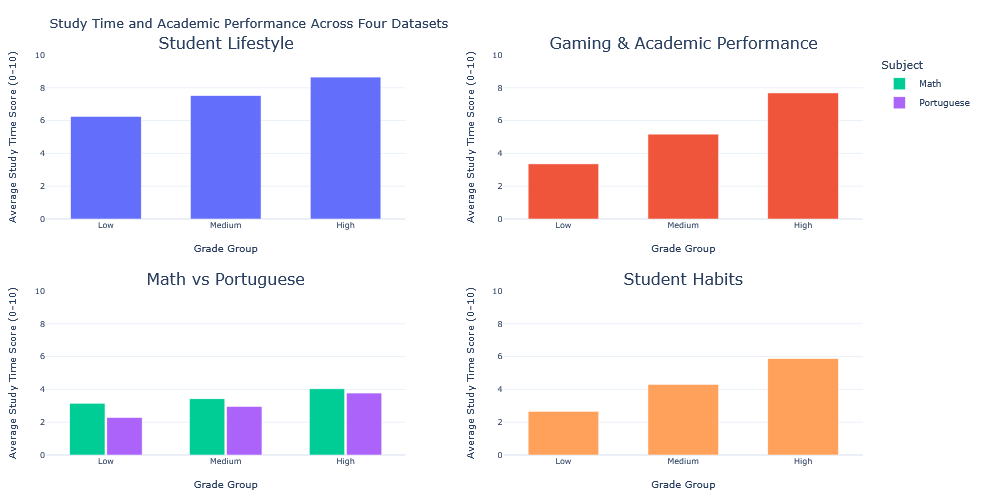

In [11]:
import plotly.graph_objects as go
from plotly.subplots import make_subplots

grade_order = ["Low", "Medium", "High"]

# Copy to avoid changing original data
df1 = df1.copy()
df2 = df2.copy()
df3 = df3.copy()
df4 = df4.copy()

# Dataset 1 and 2 are already on a 0/1–10 hour scale, so keep them
df1["study_scaled"] = df1["Study_Hours_Per_Day"]
df2["study_scaled"] = df2["study_hours"]

# Dataset 3: ordinal study time category 1–4, rescaled to 0–10
df3["study_scaled"] = (
    (df3["studytime"] - df3["studytime"].min()) /
    (df3["studytime"].max() - df3["studytime"].min())
) * 10

# Dataset 4: 0–8.3 hours, rescaled to 0–10
df4["study_scaled"] = (
    (df4["study_hours_per_day"] - df4["study_hours_per_day"].min()) /
    (df4["study_hours_per_day"].max() - df4["study_hours_per_day"].min())
) * 10

s1 = df1.groupby("Grade Group", observed=False)["study_scaled"].mean().reindex(grade_order)
s2 = df2.groupby("Grade Group", observed=False)["study_scaled"].mean().reindex(grade_order)

s3 = (
    df3.groupby(["Grade Group", "Subject"], observed=False)["study_scaled"]
    .mean()
    .reset_index()
)

s4 = df4.groupby("Grade Group", observed=False)["study_scaled"].mean().reindex(grade_order)

fig = make_subplots(
    rows=2,
    cols=2,
    subplot_titles=[
        "Student Lifestyle",
        "Gaming & Academic Performance",
        "Math vs Portuguese",
        "Student Habits"
    ],
    vertical_spacing=0.18,
    horizontal_spacing=0.12
)

fig.add_trace(go.Bar(x=grade_order, y=s1.values, showlegend=False), row=1, col=1)
fig.add_trace(go.Bar(x=grade_order, y=s2.values, showlegend=False), row=1, col=2)

for subject in ["Math", "Portuguese"]:
    temp = s3[s3["Subject"] == subject].set_index("Grade Group").reindex(grade_order)
    fig.add_trace(
        go.Bar(x=grade_order, y=temp["study_scaled"], name=subject),
        row=2,
        col=1
    )

fig.add_trace(go.Bar(x=grade_order, y=s4.values, showlegend=False), row=2, col=2)

fig.update_layout(
    title_text="Study Time and Academic Performance Across Four Datasets",
    barmode="group",
    height=500,
    width=700,
    template="plotly_white",
    legend_title_text="Subject",
    bargap=0.38,
    bargroupgap=0.05,
    margin=dict(l=35, r=15, t=55, b=35),
    font=dict(size=9),
    title_font=dict(size=13)
)

fig.update_xaxes(
    title_text="Grade Group",
    title_font=dict(size=10),
    tickfont=dict(size=8)
)

fig.update_yaxes(
    title_text="Average Study Time Score (0–10)",
    range=[0, 10],
    title_font=dict(size=10),
    tickfont=dict(size=8)
)

fig.show()